In [6]:
import numpy as np
dat=np.load('/home/maria/SelfStudyThesis/data/allen_natural_scenes_four_class_composite.npy',allow_pickle=True).item()
print(dat.keys())
print(dat)
neural_event_probs=dat['X']
labels=dat['stimulus_metadata']['label']

dict_keys(['X', 'neuron_metadata', 'stimulus_metadata', 'label_names', 'session_metadata', 'session_neuron_counts', 'session_valid_trial_counts', 'session_nan_counts_before_trial_average', 'session_nan_counts_after_trial_average', 'used_files', 'skipped_files', 'constants', 'description'])
{'X': array([[0.02, 0.02, 0.04, ..., 0.04, 0.02, 0.  ],
       [0.18, 0.22, 0.44, ..., 0.14, 0.14, 0.14],
       [0.04, 0.04, 0.12, ..., 0.02, 0.02, 0.02],
       ...,
       [0.12, 0.08, 0.  , ..., 0.1 , 0.06, 0.  ],
       [0.  , 0.  , 0.  , ..., 0.02, 0.04, 0.  ],
       [0.12, 0.06, 0.1 , ..., 0.08, 0.12, 0.14]], shape=(40064, 118)), 'neuron_metadata': {'cell_specimen_id': array([517407351, 517408028, 517408183, ..., 738943753, 738944319,
       738941869], shape=(40064,)), 'brain_area': array(['VISp', 'VISp', 'VISp', ..., 'VISpm', 'VISpm', 'VISpm'],
      shape=(40064,), dtype=object), 'ophys_experiment_id': array([500860585, 500860585, 500860585, ..., 717214654, 717214654,
       717214654], sh

DATA
X shape: (118, 40064)
n stimuli: 118
n features: 40064
animals: 57
non-animals: 61

Running PCA logistic LOO...
Running nested sparse logistic LOO...
Fold 118/118 | C=4.329 | selected=2751

PCA(100) + logistic
Accuracy:          0.7203
Balanced accuracy: 0.7197
ROC AUC:           0.7656

Confusion matrix:
[[45 16]
 [17 40]]

Sparse L1 logistic
Accuracy:          0.6271
Balanced accuracy: 0.6244
ROC AUC:           0.6842

Confusion matrix:
[[43 18]
 [26 31]]

SPARSITY
Original dimensions d:       40064
Mean selected features:      517.9
Median selected features s:  435
Min selected:                18
Max selected:                1540

Median fraction retained: 1.0858%

RIGOLLET-STYLE COMPLEXITY
d / n                = 339.525
s log(d) / n         = 39.070

Interpretation:
Dense estimation asks us to estimate a general 40064-dimensional decoder.
Sparse estimation asks us to discover approximately 435 useful coordinates among 40064 candidates.

FINAL SPARSE DECODER
C = 12.3285
Selecte

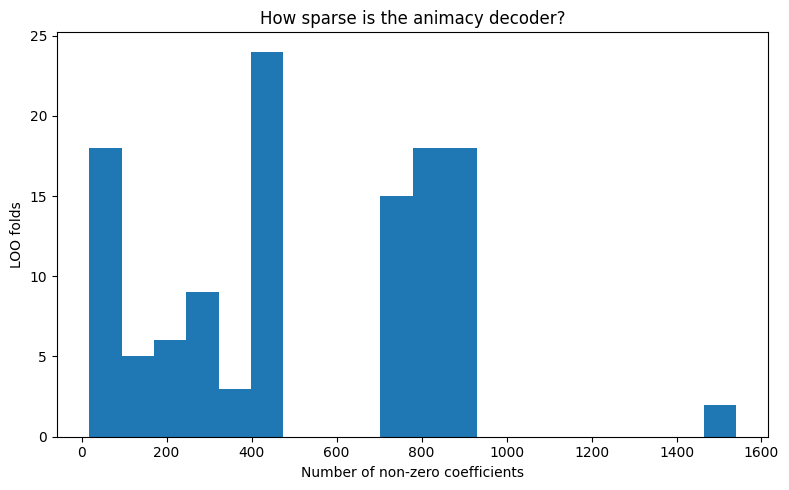

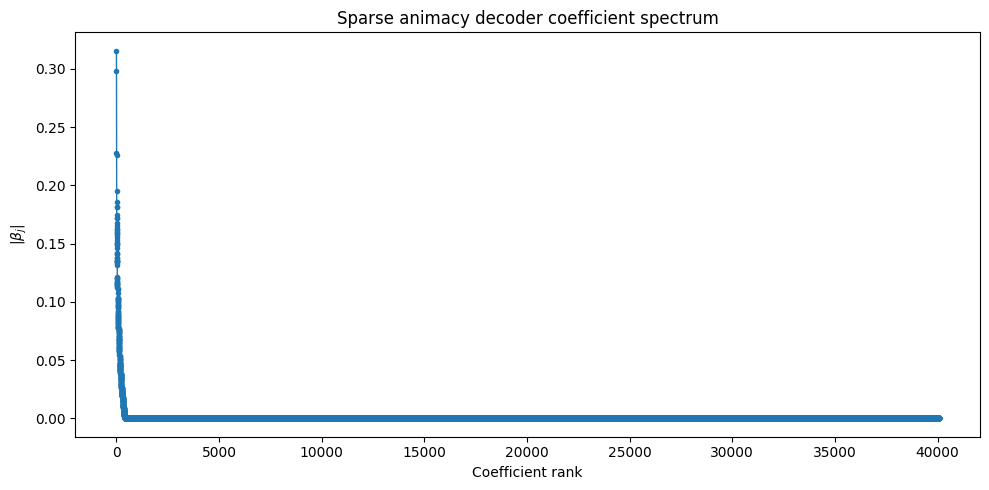

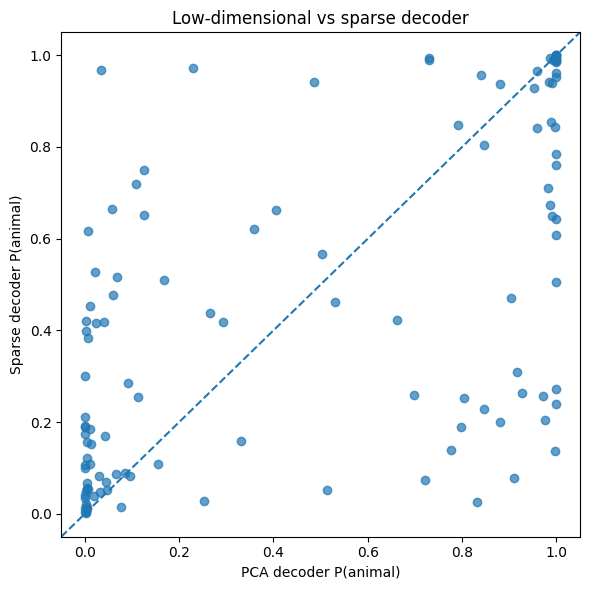

In [ ]:
"""
Sparse animacy decoding experiment
===================================

Question:
    Is animacy information better described by

    A) a low-dimensional distributed population code (PCA + logistic), or
    B) a sparse neuron-level code (L1 logistic)?

Sparse high-dimensional intuition:

              s log(d)
        rate ~ --------
                 n

rather than d/n, under appropriate sparsity/design assumptions.

IMPORTANT:
Regularization strength C is selected INSIDE each outer CV fold.
The held-out stimulus therefore never participates in hyperparameter
selection or feature preprocessing.
"""

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    LeaveOneOut,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)


# ============================================================
# 1. LOAD DATA
# ============================================================

path = (
    "/home/maria/SelfStudyThesis/data/"
    "allen_natural_scenes_four_class_composite.npy"
)

dat = np.load(path, allow_pickle=True).item()

X = np.asarray(dat["X"], dtype=float)
labels = np.asarray(dat["stimulus_metadata"]["label"])


# Original:
#   0 = animal
#   1,2,3 = non-animal
#
# Binary:
#   1 = animal
#   0 = non-animal

y = (labels == 0).astype(int)


print("=" * 70)
print("DATA")
print("=" * 70)

print("X shape:", X.shape)
print("n stimuli:", len(y))
print("n features:", X.shape[1])
print("animals:", y.sum())
print("non-animals:", (1-y).sum())


n, d = X.shape


# ============================================================
# 2. BASELINE: PCA + LOGISTIC
# ============================================================
#
# This is the "distributed but low-dimensional" hypothesis.
#
# IMPORTANT:
# PCA is fitted inside each training fold through Pipeline.
#

loo = LeaveOneOut()

# Cannot have more PCA components than training samples.
# Choose 100 if possible.

pca_k = min(100, n - 2)


pca_model = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=pca_k)),
    ("logistic", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=5000,
    ))
])


print("\nRunning PCA logistic LOO...")

pca_prob = cross_val_predict(
    pca_model,
    X,
    y,
    cv=loo,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

pca_pred = (pca_prob >= 0.5).astype(int)


# ============================================================
# 3. SPARSE L1 LOGISTIC
# ============================================================
#
# Rigollet-style structural assumption:
#
#       beta is sparse
#
# Instead of reducing X to PCA coordinates, keep the original
# neuron dimensions and penalize:
#
#                   ||beta||_1
#
# which drives many coefficients exactly to zero.
#
# sklearn parameterizes penalty strength using C:
#
#             smaller C = stronger regularization
#

Cs = np.logspace(-3, 2, 12)

outer = LeaveOneOut()

sparse_prob = np.zeros(n)
chosen_C = np.zeros(n)
n_selected = np.zeros(n)


print("Running nested sparse logistic LOO...")

for fold, (train_idx, test_idx) in enumerate(outer.split(X, y), 1):

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_test = X[test_idx]

    # Inner CV chooses sparsity strength using training data ONLY.
    inner_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    sparse_pipe = Pipeline([
        ("scale", StandardScaler()),
        ("logistic", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=5000,
        ))
    ])

    search = GridSearchCV(
        sparse_pipe,
        param_grid={"logistic__C": Cs},
        scoring="balanced_accuracy",
        cv=inner_cv,
        n_jobs=-1,
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    sparse_prob[test_idx] = best_model.predict_proba(X_test)[:, 1]

    chosen_C[test_idx] = search.best_params_["logistic__C"]

    beta = best_model.named_steps["logistic"].coef_[0]

    n_selected[test_idx] = np.sum(np.abs(beta) > 1e-10)

    if fold % 10 == 0 or fold == n:
        print(
            f"\rFold {fold:3d}/{n} | "
            f"C={chosen_C[test_idx][0]:.4g} | "
            f"selected={int(n_selected[test_idx][0])}",
            end=""
        )

print("\n")

sparse_pred = (sparse_prob >= 0.5).astype(int)


# ============================================================
# 4. METRICS
# ============================================================

def report(name, y, pred, prob):

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        f"Accuracy:          {accuracy_score(y, pred):.4f}"
    )

    print(
        f"Balanced accuracy: "
        f"{balanced_accuracy_score(y, pred):.4f}"
    )

    print(
        f"ROC AUC:           {roc_auc_score(y, prob):.4f}"
    )

    print("\nConfusion matrix:")
    print(confusion_matrix(y, pred))
    print()


report(
    f"PCA({pca_k}) + logistic",
    y,
    pca_pred,
    pca_prob,
)

report(
    "Sparse L1 logistic",
    y,
    sparse_pred,
    sparse_prob,
)


# ============================================================
# 5. HOW MUCH DID L1 ACTUALLY PRUNE?
# ============================================================

median_s = int(np.median(n_selected))
mean_s = np.mean(n_selected)

print("=" * 70)
print("SPARSITY")
print("=" * 70)

print(f"Original dimensions d:       {d}")
print(f"Mean selected features:      {mean_s:.1f}")
print(f"Median selected features s:  {median_s}")
print(f"Min selected:                {int(n_selected.min())}")
print(f"Max selected:                {int(n_selected.max())}")

print(
    f"\nMedian fraction retained: "
    f"{median_s/d:.4%}"
)


# ============================================================
# 6. THE RIGOLLET NUMBER :-)
# ============================================================
#
# Illustrative high-dimensional complexity:
#
#             s log(d)
#             --------
#                n
#
# versus the unstructured d/n.
#
# Don't interpret these literally as prediction error.
# They illustrate the scaling of the statistical problem.
#

dense_complexity = d / n

sparse_complexity = (
    median_s * np.log(d) / n
)

print("\n" + "=" * 70)
print("RIGOLLET-STYLE COMPLEXITY")
print("=" * 70)

print(
    f"d / n                = "
    f"{dense_complexity:.3f}"
)

print(
    f"s log(d) / n         = "
    f"{sparse_complexity:.3f}"
)

print(
    "\nInterpretation:"
)

print(
    "Dense estimation asks us to estimate a general "
    f"{d}-dimensional decoder."
)

print(
    "Sparse estimation asks us to discover approximately "
    f"{median_s} useful coordinates among {d} candidates."
)


# ============================================================
# 7. FIT ONE FINAL SPARSE MODEL
# ============================================================
#
# This is NOT used for evaluating accuracy.
#
# We fit the complete dataset merely to inspect which neurons
# the sparse decoder chooses.
#

final_C = np.median(chosen_C)

final_model = Pipeline([
    ("scale", StandardScaler()),
    ("logistic", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=final_C,
        max_iter=5000,
    ))
])

final_model.fit(X, y)

beta = final_model.named_steps["logistic"].coef_[0]

selected = np.flatnonzero(np.abs(beta) > 1e-10)

order = selected[
    np.argsort(np.abs(beta[selected]))[::-1]
]


print("\n" + "=" * 70)
print("FINAL SPARSE DECODER")
print("=" * 70)

print(f"C = {final_C:.6g}")
print(f"Selected {len(selected)} / {d} features")

print("\nTop 20 coefficients:")

for j in order[:20]:

    print(
        f"feature {j:6d}    "
        f"beta={beta[j]: .5f}"
    )


# ============================================================
# 8. PLOTS
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    n_selected,
    bins=20,
)

plt.xlabel("Number of non-zero coefficients")
plt.ylabel("LOO folds")
plt.title("How sparse is the animacy decoder?")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    np.sort(np.abs(beta))[::-1],
    marker=".",
    linewidth=1,
)

plt.xlabel("Coefficient rank")
plt.ylabel(r"$|\beta_j|$")
plt.title("Sparse animacy decoder coefficient spectrum")
plt.tight_layout()
plt.show()


# Compare predictions directly

plt.figure(figsize=(6, 6))

plt.scatter(
    pca_prob,
    sparse_prob,
    alpha=0.7,
)

plt.axline(
    (0, 0),
    (1, 1),
    linestyle="--",
)

plt.xlabel("PCA decoder P(animal)")
plt.ylabel("Sparse decoder P(animal)")
plt.title("Low-dimensional vs sparse decoder")
plt.tight_layout()
plt.show()

DATA
X: (118, 40064)
animals: 57
non-animals: 61

d/n = 339.52542372881356
log(d) = 10.59823345445977

NESTED LOO
Finished fold   5/118 | PCA k=80 | L1 selected=  718
Finished fold  10/118 | PCA k=60 | L1 selected=  729
Finished fold  15/118 | PCA k=60 | L1 selected=  703
Finished fold  20/118 | PCA k=40 | L1 selected=   45
Finished fold  25/118 | PCA k=60 | L1 selected= 1566
Finished fold  30/118 | PCA k=60 | L1 selected=  859
Finished fold  35/118 | PCA k=60 | L1 selected=  860
Finished fold  40/118 | PCA k=40 | L1 selected= 1544
Finished fold  45/118 | PCA k=60 | L1 selected=  351
Finished fold  50/118 | PCA k=40 | L1 selected=  415
Finished fold  55/118 | PCA k=20 | L1 selected=  368
Finished fold  60/118 | PCA k=80 | L1 selected=  236
Finished fold  65/118 | PCA k=60 | L1 selected=   47
Finished fold  70/118 | PCA k=20 | L1 selected=  695
Finished fold  75/118 | PCA k=40 | L1 selected=  722
Finished fold  80/118 | PCA k=40 | L1 selected=  718
Finished fold  85/118 | PCA k=40 | L1 

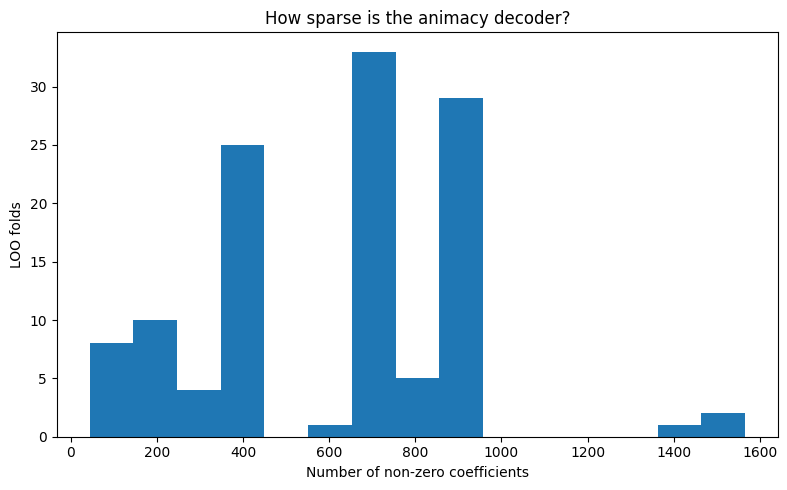

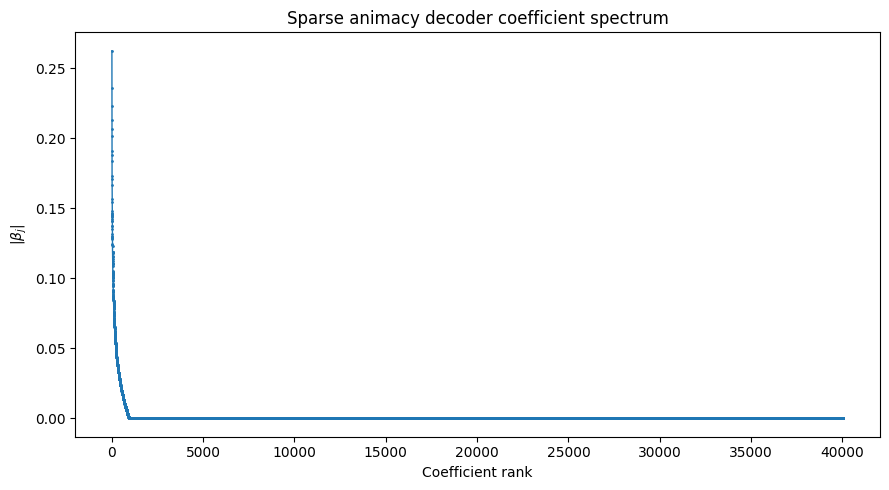

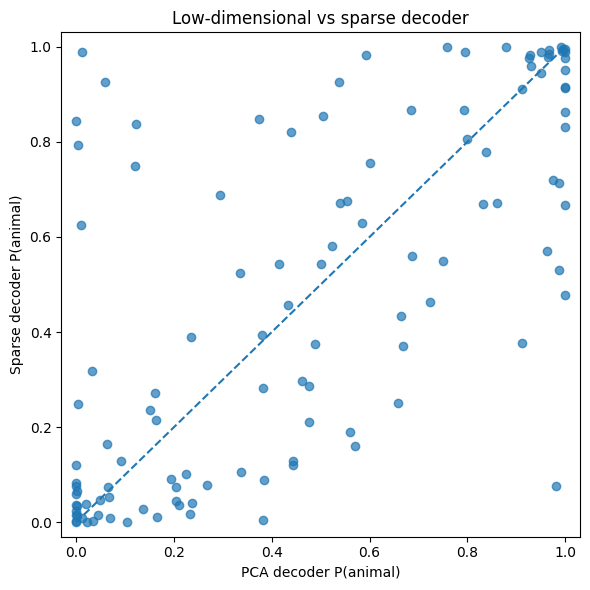

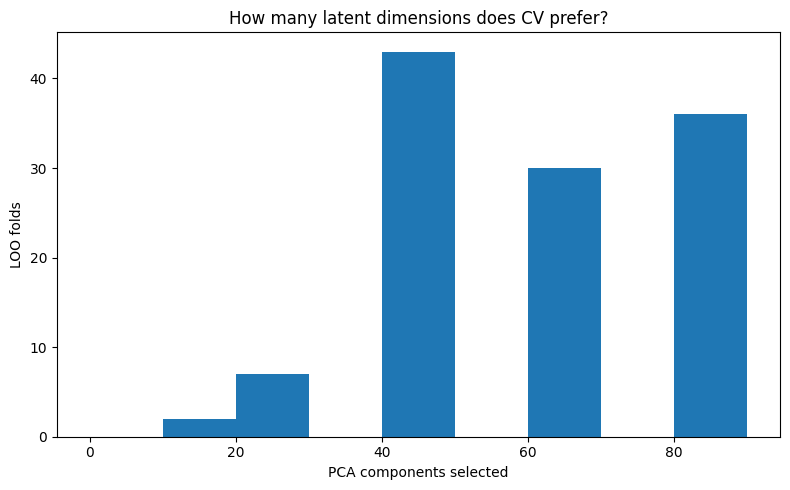


BOTTOM LINE
PCA balanced accuracy: 0.6425
L1  balanced accuracy: 0.6267
PCA AUC: 0.7299
L1  AUC: 0.7112

Median PCA dimension: 60
Median L1 support: 704

Question answered by this experiment:
Does animacy generalize better when we assume that the neural signal is LOW-DIMENSIONAL (PCA), or when we assume it is SPARSE in neuron coordinates (L1)?


In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.model_selection import (
    LeaveOneOut,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. LOAD DATA
# ============================================================

PATH = "/home/maria/SelfStudyThesis/data/allen_natural_scenes_four_class_composite.npy"

dat = np.load(PATH, allow_pickle=True).item()

X = np.asarray(dat["X"], dtype=np.float64).T
labels = np.asarray(dat["stimulus_metadata"]["label"])

# Original:
#   0 = animal
#   1,2,3 = non-animal
#
# Binary target:
#   y=1 = animal
#   y=0 = non-animal
y = (labels == 0).astype(int)

n, d = X.shape

print("=" * 72)
print("DATA")
print("=" * 72)
print("X:", X.shape)
print("animals:", y.sum())
print("non-animals:", n - y.sum())
print()
print("d/n =", d / n)
print("log(d) =", np.log(d))


# ============================================================
# 2. MODELS
# ============================================================

# ------------------------------------------------------------
# PCA decoder
#
# IMPORTANT:
# PCA is fitted INSIDE the inner CV.
#
# Outer LOO:
#   118 -> 117 training samples
#
# Inner 4-fold CV:
#   smallest training fold has only ~87 samples
#
# Therefore PCA(100) is illegal.
# ------------------------------------------------------------

PCA_COMPONENTS = [5, 10, 20, 40, 60, 80]
PCA_C_VALUES = np.logspace(-3, 3, 7)

pca_pipe = Pipeline([
    (
        "scale",
        StandardScaler(),
    ),
    (
        "pca",
        PCA(
            svd_solver="randomized",
            random_state=0,
        ),
    ),
    (
        "logistic",
        LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
        ),
    ),
])

pca_grid = {
    "pca__n_components": PCA_COMPONENTS,
    "logistic__C": PCA_C_VALUES,
}


# ------------------------------------------------------------
# Sparse L1 decoder
#
# Rigollet-style idea:
#
#       beta_hat =
#       argmin_beta [
#           empirical logistic loss
#           + lambda ||beta||_1
#       ]
#
# L1 regularization encourages many beta_j = 0.
#
# Instead of estimating a completely unrestricted
# 40,064-dimensional direction, we ask whether the
# useful decoder can be represented by a sparse subset.
# ------------------------------------------------------------

L1_C_VALUES = np.logspace(-4, 2, 13)

l1_pipe = Pipeline([
    (
        "scale",
        StandardScaler(),
    ),
    (
        "logistic",
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=5000,
        ),
    ),
])

l1_grid = {
    "logistic__C": L1_C_VALUES,
}


# ============================================================
# 3. NESTED LEAVE-ONE-OUT
# ============================================================

loo = LeaveOneOut()

pca_prob = np.zeros(n)
l1_prob = np.zeros(n)

pca_best_k = np.zeros(n, dtype=int)
pca_best_C = np.zeros(n)

l1_best_C = np.zeros(n)
l1_selected = np.zeros(n, dtype=int)

print()
print("=" * 72)
print("NESTED LOO")
print("=" * 72)

for fold, (train_idx, test_idx) in enumerate(loo.split(X), start=1):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]

    # Fresh inner CV for this outer fold.
    inner = StratifiedKFold(
        n_splits=4,
        shuffle=True,
        random_state=fold,
    )

    # ========================================================
    # PCA + logistic
    # ========================================================

    pca_search = GridSearchCV(
        estimator=clone(pca_pipe),
        param_grid=pca_grid,
        scoring="balanced_accuracy",
        cv=inner,
        n_jobs=-1,
        refit=True,

        # Don't silently convert programming/model errors
        # into NaNs.
        error_score="raise",
    )

    pca_search.fit(X_train, y_train)

    pca_prob[test_idx[0]] = (
        pca_search.predict_proba(X_test)[0, 1]
    )

    pca_best_k[test_idx[0]] = (
        pca_search.best_params_["pca__n_components"]
    )

    pca_best_C[test_idx[0]] = (
        pca_search.best_params_["logistic__C"]
    )

    # ========================================================
    # Sparse L1 logistic
    # ========================================================

    l1_search = GridSearchCV(
        estimator=clone(l1_pipe),
        param_grid=l1_grid,
        scoring="balanced_accuracy",
        cv=inner,
        n_jobs=-1,
        refit=True,
        error_score="raise",
    )

    l1_search.fit(X_train, y_train)

    l1_prob[test_idx[0]] = (
        l1_search.predict_proba(X_test)[0, 1]
    )

    l1_best_C[test_idx[0]] = (
        l1_search.best_params_["logistic__C"]
    )

    beta = (
        l1_search
        .best_estimator_
        .named_steps["logistic"]
        .coef_[0]
    )

    l1_selected[test_idx[0]] = np.count_nonzero(beta)

    if fold % 5 == 0 or fold == n:
        print(
            f"Finished fold {fold:3d}/{n} | "
            f"PCA k={pca_best_k[test_idx[0]]:2d} | "
            f"L1 selected={l1_selected[test_idx[0]]:5d}"
        )


# ============================================================
# 4. PERFORMANCE
# ============================================================

pca_pred = (pca_prob >= 0.5).astype(int)
l1_pred = (l1_prob >= 0.5).astype(int)


def report(name, y_true, pred, prob):

    print()
    print("=" * 72)
    print(name)
    print("=" * 72)

    print(
        f"Accuracy:          "
        f"{accuracy_score(y_true, pred):.4f}"
    )

    print(
        f"Balanced accuracy: "
        f"{balanced_accuracy_score(y_true, pred):.4f}"
    )

    print(
        f"ROC AUC:           "
        f"{roc_auc_score(y_true, prob):.4f}"
    )

    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_true, pred))


report(
    "PCA + logistic",
    y,
    pca_pred,
    pca_prob,
)

report(
    "Sparse L1 logistic",
    y,
    l1_pred,
    l1_prob,
)


# ============================================================
# 5. WHAT DIMENSION DOES PCA PREFER?
# ============================================================

print()
print("=" * 72)
print("PCA DIMENSION")
print("=" * 72)

values, counts = np.unique(
    pca_best_k,
    return_counts=True,
)

for value, count in zip(values, counts):
    print(
        f"k={value:3d}: "
        f"{count:3d} outer folds"
    )

print()
print(
    "Median selected PCA dimension:",
    np.median(pca_best_k),
)


# ============================================================
# 6. SPARSITY
# ============================================================

median_s = int(np.median(l1_selected))
mean_s = np.mean(l1_selected)

print()
print("=" * 72)
print("SPARSITY")
print("=" * 72)

print(f"Original dimensions d:       {d}")
print(f"Mean selected features:      {mean_s:.1f}")
print(f"Median selected features s:  {median_s}")
print(f"Min selected:                {l1_selected.min()}")
print(f"Max selected:                {l1_selected.max()}")

print()
print(
    "Median fraction retained: "
    f"{100 * median_s / d:.4f}%"
)


# ============================================================
# 7. RIGOLLET-STYLE COMPLEXITY
# ============================================================

dense_complexity = d / n

sparse_complexity = (
    median_s * np.log(d) / n
)

print()
print("=" * 72)
print("RIGOLLET-STYLE COMPLEXITY")
print("=" * 72)

print(
    f"d / n                = "
    f"{dense_complexity:.3f}"
)

print(
    f"s log(d) / n         = "
    f"{sparse_complexity:.3f}"
)

print()
print(
    "Sparse high-dimensional estimation becomes attractive "
    "when s << d."
)

print(
    "Here the empirical question is whether the animacy "
    "decoder is genuinely sparse and stable enough for "
    "that assumption to help prediction."
)


# ============================================================
# 8. FIT FINAL SPARSE MODEL
#
# This model is NOT used to estimate test performance.
# Nested LOO above already did that.
#
# We fit this only so that we can inspect the neural
# coefficients after choosing C by CV.
# ============================================================

final_inner = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123,
)

final_search = GridSearchCV(
    estimator=clone(l1_pipe),
    param_grid=l1_grid,
    scoring="balanced_accuracy",
    cv=final_inner,
    n_jobs=-1,
    refit=True,
    error_score="raise",
)

final_search.fit(X, y)

final_model = final_search.best_estimator_

beta = (
    final_model
    .named_steps["logistic"]
    .coef_[0]
)

selected = np.flatnonzero(beta)

print()
print("=" * 72)
print("FINAL SPARSE DECODER")
print("=" * 72)

print(
    "C =",
    final_search.best_params_["logistic__C"],
)

print(
    f"Selected {len(selected)} / {d} features"
)


# ============================================================
# 9. TOP COEFFICIENTS
# ============================================================

order = np.argsort(np.abs(beta))[::-1]

print()
print("Top 20 coefficients:")

for j in order[:20]:
    print(
        f"feature {j:6d}    "
        f"beta={beta[j]: .5f}"
    )


# ============================================================
# 10. PLOTS
# ============================================================

# ------------------------------------------------------------
# A. How many features survived L1 in each LOO fold?
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    l1_selected,
    bins=15,
)

plt.xlabel("Number of non-zero coefficients")
plt.ylabel("LOO folds")
plt.title("How sparse is the animacy decoder?")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# B. Coefficient spectrum
# ------------------------------------------------------------

sorted_abs_beta = np.sort(
    np.abs(beta)
)[::-1]

plt.figure(figsize=(9, 5))

plt.plot(
    sorted_abs_beta,
    marker=".",
    markersize=2,
    linewidth=1,
)

plt.xlabel("Coefficient rank")
plt.ylabel(r"$|\beta_j|$")
plt.title(
    "Sparse animacy decoder coefficient spectrum"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# C. Compare predictions
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    pca_prob,
    l1_prob,
    alpha=0.7,
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
)

plt.xlabel("PCA decoder P(animal)")
plt.ylabel("Sparse decoder P(animal)")
plt.title(
    "Low-dimensional vs sparse decoder"
)

plt.xlim(-0.03, 1.03)
plt.ylim(-0.03, 1.03)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# D. PCA dimensionality chosen across folds
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    pca_best_k,
    bins=np.arange(0, 91, 10),
)

plt.xlabel("PCA components selected")
plt.ylabel("LOO folds")
plt.title(
    "How many latent dimensions does CV prefer?"
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. FINAL COMPARISON
# ============================================================

print()
print("=" * 72)
print("BOTTOM LINE")
print("=" * 72)

print(
    f"PCA balanced accuracy: "
    f"{balanced_accuracy_score(y, pca_pred):.4f}"
)

print(
    f"L1  balanced accuracy: "
    f"{balanced_accuracy_score(y, l1_pred):.4f}"
)

print(
    f"PCA AUC: "
    f"{roc_auc_score(y, pca_prob):.4f}"
)

print(
    f"L1  AUC: "
    f"{roc_auc_score(y, l1_prob):.4f}"
)

print()
print(
    "Median PCA dimension:",
    int(np.median(pca_best_k)),
)

print(
    "Median L1 support:",
    median_s,
)

print()
print(
    "Question answered by this experiment:"
)

print(
    "Does animacy generalize better when we assume that "
    "the neural signal is LOW-DIMENSIONAL (PCA), or when "
    "we assume it is SPARSE in neuron coordinates (L1)?"
)

In [15]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

model = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=100)),
    ("logistic", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=5000,
    )),
])

prob = cross_val_predict(
    model,
    X,
    y,
    cv=LeaveOneOut(),
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

pred = (prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y, pred))
print("Balanced accuracy:", balanced_accuracy_score(y, pred))
print("AUC:", roc_auc_score(y, prob))

Accuracy: 0.7203389830508474
Balanced accuracy: 0.7197296519988496
AUC: 0.7656025309174576
